<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/CRNN_Text_Recognition_Python38_Compatible.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning OCR: CRNN Text Recognition in Images — Self-Contained

**Portfolio project:** Build an end-to-end neural OCR system that reads a cropped, single-line text image.

This notebook covers the business objective, synthetic data creation, exploratory analysis, preprocessing, CRNN architecture, CTC loss, training, evaluation, prediction, model saving, error analysis, and deployment extensions.

> This is an original implementation intended for learning and portfolio use. It reproduces the general CRNN/CTC workflow, not proprietary source code.
> This notebook contains all helper functions internally and does not require a `src` folder.


## 1. Problem definition

### Objective
Given an image containing one line of text, predict the complete character sequence.

### Example applications
- Product serial numbers
- License or asset identifiers
- Shipping labels
- Meter and instrument readings
- Cropped form fields

### Important scope distinction
This model performs **text recognition** on cropped text-line images. A complete scene-text system would first locate text regions using a detector such as CRAFT or DBNet, crop them, and then pass each crop to this recognizer.

In [1]:
from pathlib import Path
import random
import string
import time
from typing import Iterable, Union, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def random_text(min_len: int = 3, max_len: int = 10) -> str:
    alphabet = string.ascii_uppercase + string.digits
    length = random.randint(min_len, max_len)
    return "".join(random.choice(alphabet) for _ in range(length))

def render_text_image(text: str, width: int = 160, height: int = 48, noise: bool = True) -> Image.Image:
    background = random.randint(225, 255)
    image = Image.new("L", (width, height), color=background)
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    scale = min((width-16)/max(tw,1), (height-12)/max(th,1))
    canvas = Image.new("L", (max(tw,1), max(th,1)), color=background)
    ImageDraw.Draw(canvas).text((0,0), text, fill=random.randint(0,40), font=font)
    if scale > 1:
        canvas = canvas.resize((max(1,int(canvas.width*scale)), max(1,int(canvas.height*scale))), Image.Resampling.BICUBIC)
    x = max(0, (width-canvas.width)//2 + random.randint(-4,4))
    y = max(0, (height-canvas.height)//2 + random.randint(-3,3))
    image.paste(canvas, (x,y))
    if noise:
        if random.random() < 0.35:
            image = image.filter(ImageFilter.GaussianBlur(random.uniform(0.1,0.8)))
        arr = np.asarray(image, dtype=np.float32)
        arr += np.random.normal(0, random.uniform(0,7), arr.shape)
        image = Image.fromarray(np.clip(arr,0,255).astype(np.uint8))
    return image

def create_synthetic_dataset(output_dir: Union[str, Path], count: int = 1000, seed: int = 42):
    seed_everything(seed)
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    records=[]
    for idx in range(count):
        label=random_text()
        path=output / f"sample_{idx:06d}.png"
        render_text_image(label).save(path)
        records.append({"image_path": str(path), "label": label})
    return records

def levenshtein(a: str, b: str) -> int:
    previous=list(range(len(b)+1))
    for i,ca in enumerate(a, start=1):
        current=[i]
        for j,cb in enumerate(b, start=1):
            current.append(min(current[-1]+1, previous[j]+1, previous[j-1]+(ca!=cb)))
        previous=current
    return previous[-1]

def character_error_rate(targets: Iterable[str], predictions: Iterable[str]) -> float:
    edits=0
    chars=0
    for target,prediction in zip(targets,predictions):
        edits += levenshtein(target,prediction)
        chars += max(len(target),1)
    return edits/max(chars,1)

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


### Please restart the runtime

After running the cell above, please restart the Colab runtime by navigating to 'Runtime' > 'Restart runtime...' in the menu above. This will ensure the reinstalled pandas library is loaded correctly.

## 2. Configuration

The image height is fixed at 48 pixels. Width is fixed at 160 pixels for efficient batching. The alphabet contains uppercase letters and digits. Index `0` is reserved for the CTC blank token.

In [2]:
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data" / "synthetic"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_WIDTH = 160
IMAGE_HEIGHT = 48
ALPHABET = string.ascii_uppercase + string.digits
BLANK_INDEX = 0

char_to_idx = {char: index + 1 for index, char in enumerate(ALPHABET)}
idx_to_char = {index: char for char, index in char_to_idx.items()}

NUM_CLASSES = len(ALPHABET) + 1
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 1e-3

print("Vocabulary size including blank:", NUM_CLASSES)

Vocabulary size including blank: 37


## 3. Generate a lightweight synthetic dataset

Large OCR datasets can be expensive to download and train. This notebook generates labeled text images locally so the complete pipeline remains reproducible.

For a stronger portfolio result, increase `NUM_SAMPLES` to 20,000 or replace the generated records with a real OCR dataset.

In [3]:
NUM_SAMPLES = 2000
records = create_synthetic_dataset(DATA_DIR, count=NUM_SAMPLES, seed=42)
df = pd.DataFrame(records)
df.head()

,image_path,label
0,data/synthetic/sample_000000.png,BRPO
1,data/synthetic/sample_000001.png,NO6B
2,data/synthetic/sample_000002.png,K1V
3,data/synthetic/sample_000003.png,QC38HYF9
4,data/synthetic/sample_000004.png,FOGYR3X


In [4]:
print(df.shape)
print("Missing values:")
print(df.isna().sum())
print("\nLabel-length summary:")
display(df["label"].str.len().describe())

(2000, 2)
Missing values:
image_path    0
label         0
dtype: int64

Label-length summary:


,label
count,2000.000000
mean,6.454000
std,2.270344
min,3.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,10.000000


## 4. Exploratory data analysis

We inspect random samples and the label-length distribution. This catches rendering problems and shows whether the dataset covers short and long sequences.

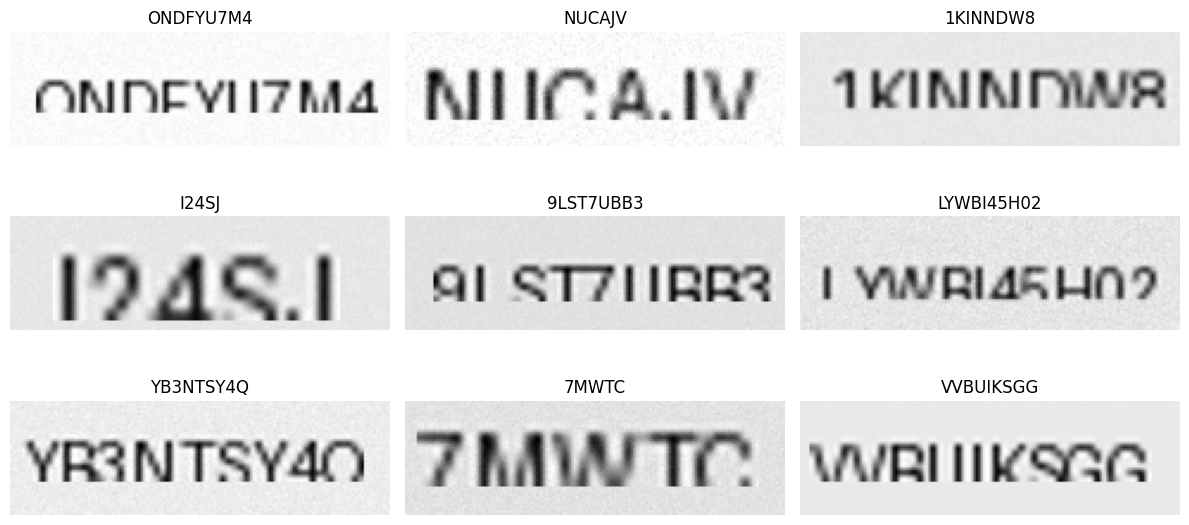

In [5]:
sample_df = df.sample(9, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 6))
for ax, row in zip(axes.ravel(), sample_df.itertuples()):
    ax.imshow(Image.open(row.image_path), cmap="gray")
    ax.set_title(row.label)
    ax.axis("off")
plt.tight_layout()
plt.show()

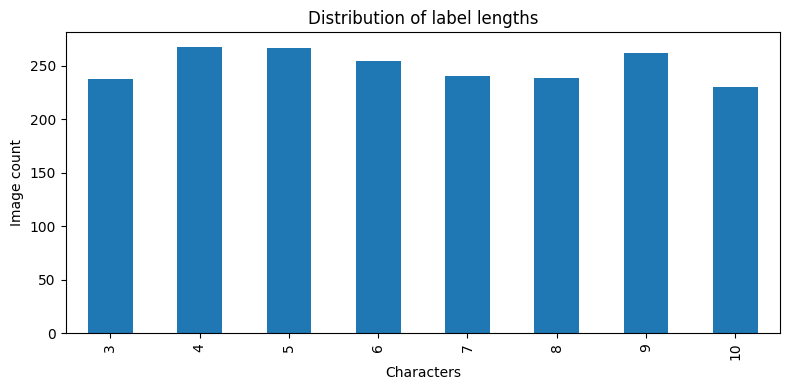

In [6]:
df["label_length"] = df["label"].str.len()
plt.figure(figsize=(8, 4))
df["label_length"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of label lengths")
plt.xlabel("Characters")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()

## 5. Dataset and preprocessing

Each image is:
1. converted to grayscale,
2. resized to the configured dimensions,
3. scaled from `[0, 255]` to `[0, 1]`,
4. normalized to approximately `[-1, 1]`.

Labels are converted from characters to integer IDs. CTC accepts concatenated targets plus the length of each target, so labels do not require manual alignment to image positions.

In [7]:
class OCRDataset(Dataset):
    def __init__(self, frame, image_width=160, image_height=48):
        self.frame = frame.reset_index(drop=True)
        self.image_width = image_width
        self.image_height = image_height

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row["image_path"]).convert("L")
        image = image.resize((self.image_width, self.image_height), Image.Resampling.BILINEAR)
        array = np.asarray(image, dtype=np.float32) / 255.0
        array = (array - 0.5) / 0.5
        tensor = torch.from_numpy(array).unsqueeze(0)

        encoded = torch.tensor(
            [char_to_idx[c] for c in row["label"]],
            dtype=torch.long,
        )
        return tensor, encoded, row["label"]


def ctc_collate(batch):
    images, encoded_labels, raw_labels = zip(*batch)
    images = torch.stack(images)
    target_lengths = torch.tensor([len(label) for label in encoded_labels], dtype=torch.long)
    targets = torch.cat(encoded_labels)
    return images, targets, target_lengths, list(raw_labels)

In [8]:
dataset = OCRDataset(df, IMAGE_WIDTH, IMAGE_HEIGHT)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=ctc_collate,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ctc_collate,
    num_workers=0,
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 1600
Validation images: 400


## 6. CRNN architecture

The convolutional layers extract visual patterns while reducing image height. The final feature map is averaged over height and rearranged so image width becomes sequence time. Two bidirectional LSTM layers then learn character context from both directions.

The network returns log-probabilities with shape:

`time steps × batch size × classes`

This is the format expected by PyTorch's CTC loss.

In [9]:
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),
        )
        self.sequence_model = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            dropout=0.2,
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, images):
        features = self.cnn(images)
        features = features.mean(dim=2)
        sequence = features.permute(2, 0, 1)
        sequence, _ = self.sequence_model(sequence)
        logits = self.classifier(sequence)
        return logits.log_softmax(dim=2)


model = CRNN(NUM_CLASSES).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(256, 

## 7. CTC decoding and metrics

Greedy CTC decoding takes the most likely class at every time step, removes repeated consecutive classes, and removes blank tokens.

We report:
- validation loss,
- Character Error Rate,
- exact-match accuracy.

In [10]:
def greedy_decode(log_probs):
    best_path = log_probs.argmax(dim=2).permute(1, 0)
    predictions = []
    for sequence in best_path:
        previous = None
        characters = []
        for token in sequence.tolist():
            if token != BLANK_INDEX and token != previous:
                characters.append(idx_to_char.get(token, ""))
            previous = token
        predictions.append("".join(characters))
    return predictions


def exact_match_accuracy(targets, predictions):
    return np.mean([target == prediction for target, prediction in zip(targets, predictions)])

## 8. Training loop

`zero_infinity=True` prevents invalid alignments from creating infinite losses. Gradient clipping helps stabilize recurrent-network training.

In [11]:
criterion = nn.CTCLoss(blank=BLANK_INDEX, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def run_epoch(model, loader, training=True):
    model.train(training)
    total_loss = 0.0
    all_targets, all_predictions = [], []

    for images, targets, target_lengths, raw_labels in loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        with torch.set_grad_enabled(training):
            log_probs = model(images)
            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=log_probs.size(0),
                dtype=torch.long,
                device=DEVICE,
            )
            loss = criterion(log_probs, targets, input_lengths, target_lengths)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = greedy_decode(log_probs.detach().cpu())
        all_targets.extend(raw_labels)
        all_predictions.extend(predictions)

    average_loss = total_loss / len(loader.dataset)
    cer = character_error_rate(all_targets, all_predictions)
    accuracy = exact_match_accuracy(all_targets, all_predictions)
    return average_loss, cer, accuracy


history = []
best_val_loss = float("inf")
start = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_cer, train_acc = run_epoch(model, train_loader, training=True)
    val_loss, val_cer, val_acc = run_epoch(model, val_loader, training=False)
    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_cer": train_cer,
        "val_cer": val_cer,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "char_to_idx": char_to_idx,
            "idx_to_char": idx_to_char,
            "config": {
                "image_width": IMAGE_WIDTH,
                "image_height": IMAGE_HEIGHT,
                "alphabet": ALPHABET,
            },
        }, MODEL_DIR / "best_crnn.pt")

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
        f"val CER {val_cer:.4f} | val accuracy {val_acc:.4f}"
    )

print(f"Training time: {(time.time() - start) / 60:.1f} minutes")

Epoch 01 | train loss 5.0300 | val loss 3.9115 | val CER 1.0000 | val accuracy 0.0000
Epoch 02 | train loss 3.9104 | val loss 3.9071 | val CER 1.0000 | val accuracy 0.0000
Epoch 03 | train loss 3.8891 | val loss 3.8784 | val CER 1.0000 | val accuracy 0.0000
Training time: 9.7 minutes


## 9. Learning curves

A healthy run generally shows decreasing training and validation loss. A widening gap between the curves indicates overfitting.

,epoch,train_loss,val_loss,train_cer,val_cer,train_accuracy,val_accuracy
0,1,5.029955,3.911529,1.032346,1.0,0.0,0.0
1,2,3.910441,3.907092,1.000000,1.0,0.0,0.0
2,3,3.889143,3.878406,1.000000,1.0,0.0,0.0


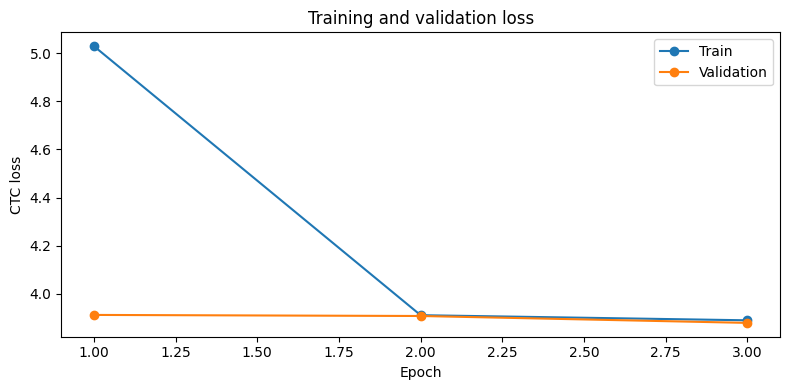

In [12]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("CTC loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

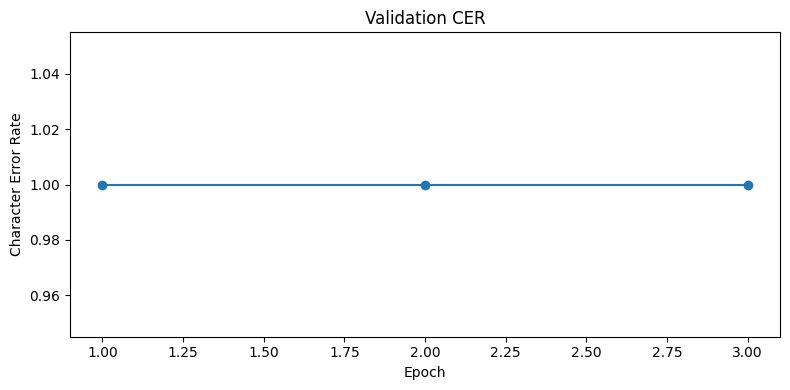

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["val_cer"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Character Error Rate")
plt.title("Validation CER")
plt.tight_layout()
plt.show()

## 10. Validation predictions

This section displays model outputs beside their ground-truth labels. During a very short CPU demonstration, errors are expected. Increase the dataset size and epoch count for a strong portfolio result.

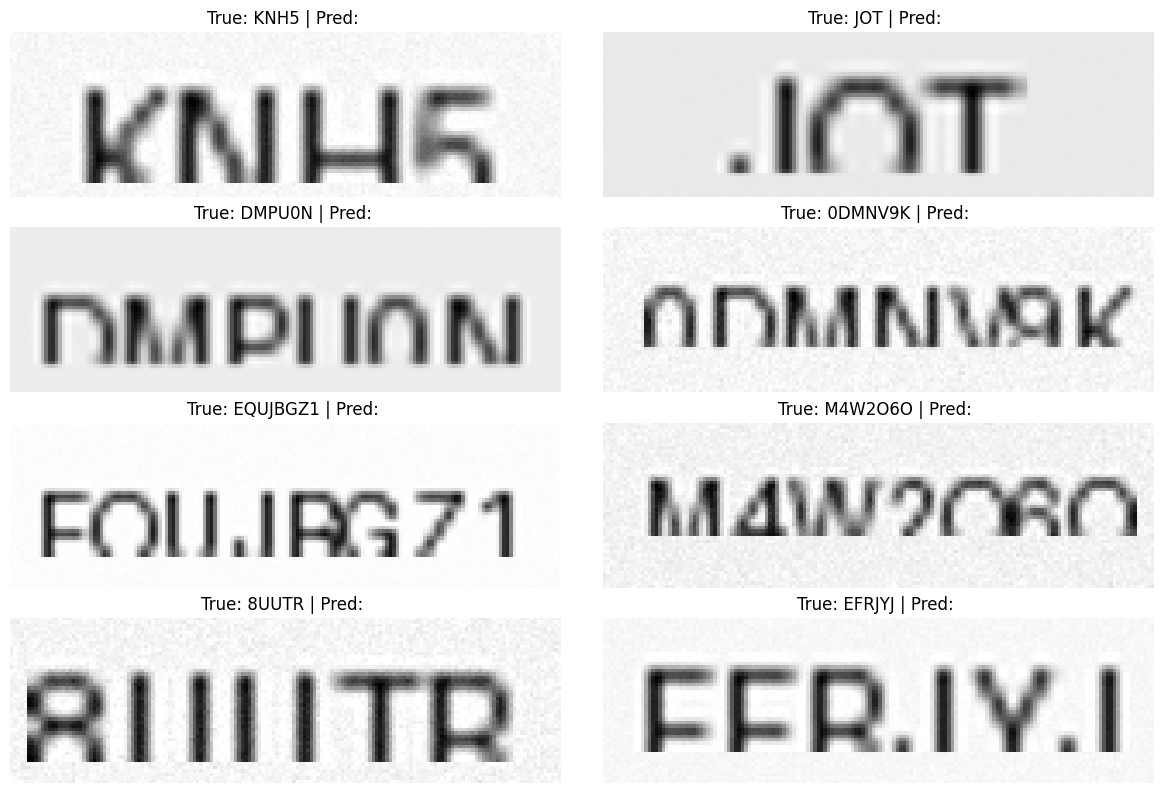

In [14]:
checkpoint = torch.load(MODEL_DIR / "best_crnn.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

images, _, _, labels = next(iter(val_loader))
with torch.no_grad():
    log_probs = model(images.to(DEVICE))
predictions = greedy_decode(log_probs.cpu())

fig, axes = plt.subplots(4, 2, figsize=(12, 8))
for ax, image, target, prediction in zip(axes.ravel(), images, labels, predictions):
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"True: {target} | Pred: {prediction}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. Error analysis

We calculate edit distance and inspect the hardest examples. This is more actionable than reporting a single score because it reveals whether errors are substitutions, missing characters, repeated characters, or total recognition failures.

In [15]:

results = []
model.eval()
with torch.no_grad():
    for images, _, _, labels in val_loader:
        predictions = greedy_decode(model(images.to(DEVICE)).cpu())
        for target, prediction in zip(labels, predictions):
            results.append({
                "target": target,
                "prediction": prediction,
                "edit_distance": levenshtein(target, prediction),
                "correct": target == prediction,
            })

results_df = pd.DataFrame(results).sort_values("edit_distance", ascending=False)
display(results_df.head(20))
results_df.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)

,target,prediction,edit_distance,correct
368,JN7BS08I4W,,10,False
375,M3GITAZVYV,,10,False
376,1QAUMU02D4,,10,False
364,NINZSQCL9I,,10,False
362,H8DMPFM5NI,,10,False
35,8PPNKFG1BK,,10,False
40,460MAUBXCU,,10,False
353,FLGSZ4FQYP,,10,False
17,2YKZETONZI,,10,False
100,KCMHMYWWJ7,,10,False


## 12. Predict a new image

Use this helper with a cropped text-line image. For photographs containing multiple text regions, add a text detector first.

In [16]:
def predict_image(image_path, model):
    image = Image.open(image_path).convert("L")
    image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.BILINEAR)
    array = np.asarray(image, dtype=np.float32) / 255.0
    array = (array - 0.5) / 0.5
    tensor = torch.from_numpy(array).unsqueeze(0).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        log_probs = model(tensor)
    return greedy_decode(log_probs.cpu())[0]


example_path = df.iloc[0]["image_path"]
print("Image:", example_path)
print("Ground truth:", df.iloc[0]["label"])
print("Prediction:", predict_image(example_path, model))

Image: data/synthetic/sample_000000.png
Ground truth: BRPO
Prediction: 


## 13. Interpretation of results

### What good performance looks like
- Training and validation loss both decline.
- Validation CER approaches zero.
- Exact-match accuracy rises.
- Predictions remain reliable across different label lengths and image degradations.

### Why a short demo may underperform
The default notebook is intentionally CPU-friendly. OCR models generally need more varied fonts, stronger augmentations, and many more images than a small demonstration run.

### Recommended portfolio experiment
Train three configurations and compare them:

| Experiment | Change | Expected insight |
|---|---|---|
| Baseline | Current CRNN | Establish starting performance |
| More data | 20,000 synthetic images | Quantify data scaling |
| Augmented | Blur, perspective, contrast | Test robustness |

Record runtime, validation CER, exact-match accuracy, parameter count, and qualitative examples.

## 14. Production and deployment roadmap

1. Add a detector such as DBNet or CRAFT for uncropped photographs.
2. Replace fixed-width distortion with aspect-ratio-preserving padding.
3. Add beam-search decoding and an optional language model.
4. Use mixed precision and GPU training.
5. Export to TorchScript or ONNX.
6. Build a Streamlit interface for image upload and OCR display.
7. Monitor confidence, CER on reviewed samples, latency, and domain drift.
8. Protect sensitive document images and define retention controls.

## 15. Resume-ready project description

**Deep Learning OCR System — PyTorch, CRNN, BiLSTM, CTC**

Developed an end-to-end optical character recognition pipeline for single-line text images using a convolutional recurrent neural network. Built reproducible data generation and preprocessing workflows, implemented CNN feature extraction and bidirectional LSTM sequence modeling, trained with CTC loss, and evaluated performance using Character Error Rate and exact-match accuracy. Added model checkpointing, qualitative prediction review, and structured error analysis, with a roadmap for scene-text detection and deployment.